In [20]:
# ================================
# 1️⃣ Imports
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [29]:
def parse_data(filename):
    X = []
    y = []
    pairs = []
    expected_feature_count = None

    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()

            # Find first feature (contains :)
            feature_start = None
            for i, token in enumerate(parts):
                if ':' in token:
                    feature_start = i
                    break

            if feature_start is None:
                continue

            try:
                # Extract label
                label = int(parts[feature_start - 1])

                # Extract pair (acronym + expansion)
                pair = " ".join(parts[:feature_start - 1])

                # Extract features
                features = []
                for token in parts[feature_start:]:
                    if ':' not in token:
                        continue

                    index, value = token.split(':', 1)

                    # Keep only numeric part
                    numeric = ""
                    for ch in value:
                        if ch in "0123456789.-":
                            numeric += ch
                        else:
                            break

                    features.append(float(numeric))

                # Determine expected feature count
                if expected_feature_count is None:
                    expected_feature_count = len(features)

                # Keep only rows with correct feature length
                if len(features) == expected_feature_count:
                    X.append(features)
                    y.append(label)
                    pairs.append(pair)

            except:
                continue

    return np.array(X, dtype=float), np.array(y, dtype=int), pairs

In [27]:
# ================================
# 3️⃣ Metric Calculation
# ================================

def calculate_metrics(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred, labels=[1, -1])
    
    TP = cm[0, 0]
    FP = cm[1, 0]
    FN = cm[0, 1]
    TN = cm[1, 1]
    
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
    
    return TP, FP, FN, TN, precision, recall, f1

In [23]:
# ================================
# 4️⃣ Confusion Matrix Plot
# ================================

def plot_confusion_matrix(cm, model_name, dataset_type):
    
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 1', 'Predicted -1'],
        yticklabels=['Actual 1', 'Actual -1']
    )
    
    plt.title(f'{model_name} - {dataset_type}')
    plt.tight_layout()
    plt.savefig(f'{model_name}_{dataset_type}_CM.png')
    plt.close()

In [24]:
# ================================
# 5️⃣ Train & Evaluate Function
# ================================

def train_and_evaluate(model, name, X_train, y_train, X_test, y_test):
    
    print("="*60)
    print(f"Training {name}")
    print("="*60)
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training metrics
    TP, FP, FN, TN, precision, recall, f1 = calculate_metrics(y_train, y_train_pred)
    train_cm = confusion_matrix(y_train, y_train_pred, labels=[1, -1])
    
    print("\nTraining Results:")
    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1-Score={f1:.4f}")
    
    plot_confusion_matrix(train_cm, name, "Training")
    
    # Test metrics
    TP, FP, FN, TN, precision, recall, f1 = calculate_metrics(y_test, y_test_pred)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=[1, -1])
    
    print("\nTest Results:")
    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1-Score={f1:.4f}")
    
    plot_confusion_matrix(test_cm, name, "Test")
    
    return f1

Loading datasets...

Training samples: 4000
Test samples: 1098
Number of features: 8
Training SVM

Training Results:
TP=1985, FP=47, FN=15, TN=1953
Precision=0.9769
Recall=0.9925
F1-Score=0.9846

Test Results:
TP=564, FP=4, FN=35, TN=495
Precision=0.9930
Recall=0.9416
F1-Score=0.9666
Training KNN

Training Results:
TP=771, FP=31, FN=1229, TN=1969
Precision=0.9613
Recall=0.3855
F1-Score=0.5503

Test Results:
TP=306, FP=2, FN=293, TN=497
Precision=0.9935
Recall=0.5109
F1-Score=0.6748
Training NaiveBayes

Training Results:
TP=1927, FP=32, FN=73, TN=1968
Precision=0.9837
Recall=0.9635
F1-Score=0.9735

Test Results:
TP=533, FP=0, FN=66, TN=499
Precision=1.0000
Recall=0.8898
F1-Score=0.9417
Training DecisionTree

Training Results:
TP=1996, FP=22, FN=4, TN=1978
Precision=0.9891
Recall=0.9980
F1-Score=0.9935

Test Results:
TP=550, FP=4, FN=49, TN=495
Precision=0.9928
Recall=0.9182
F1-Score=0.9540


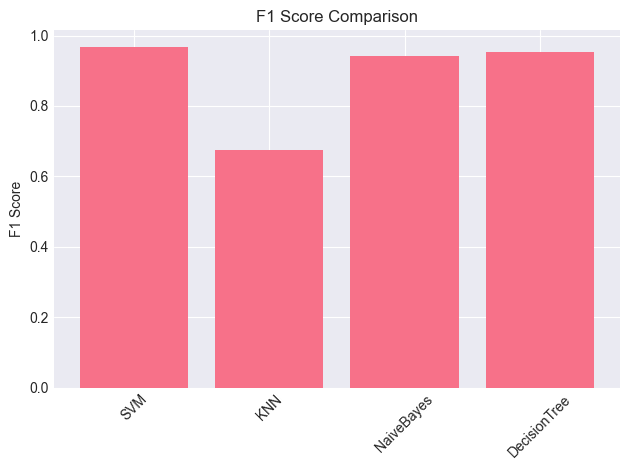


All models trained successfully!


In [25]:
# ================================
# 6️⃣ Main Execution
# ================================

def main():
    
    print("Loading datasets...\n")
    
    # Files must be in same directory as notebook
    X_train, y_train, _ = parse_data("trainingset.txt")
    X_test, y_test, _ = parse_data("testingset.txt")
    
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))
    print("Number of features:", X_train.shape[1])
    
    models = {
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale'),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "NaiveBayes": GaussianNB(),
        "DecisionTree": DecisionTreeClassifier(max_depth=10)
    }
    
    results = {}
    
    for name, model in models.items():
        f1 = train_and_evaluate(model, name, X_train, y_train, X_test, y_test)
        results[name] = f1
    
    # F1 Comparison Plot
    plt.figure()
    plt.bar(results.keys(), results.values())
    plt.title("F1 Score Comparison")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Model_Comparison.png")
    plt.show()
    
    # Save CSV
    df = pd.DataFrame(list(results.items()), columns=["Model", "F1 Score"])
    df.to_csv("results_summary.csv", index=False)
    
    print("\nAll models trained successfully!")
    

# Run
main()